# Frequency-Dependent Transaction Costs

**Docker image**: `ml4t`

This notebook demonstrates the critical tradeoff between signal quality and transaction costs
at different rebalancing frequencies.

**Key Insight**: Higher frequency strategies capture more signal but incur proportionally
more costs. The optimal cadence depends on the interaction between signal decay and cost
structure: slow signals favor monthly rebalancing, while fast-decaying signals can
justify daily trading even at retail cost levels.

**Topics Covered:**
- Break-even alpha analysis: minimum alpha needed to cover costs
- Frequency comparison: daily vs weekly vs biweekly vs monthly
- Cost erosion curves: how Sharpe degrades with frequency
- Optimal rebalancing frequency given cost structure

**Learning Objectives**
- Translate turnover assumptions into break-even alpha thresholds
- Compare gross and net Sharpe across realistic rebalancing cadences
- Model the interaction between signal decay and transaction costs
- Use cost-adjusted ranking to decide when a faster signal is still worth trading

**Book Reference:** Chapter 18: Section 18.8 (Practical Guardrails)

**Prerequisites:** Read [`01_cost_taxonomy`](01_cost_taxonomy.ipynb) for breakeven framing and
[`10_gross_vs_net_performance`](10_gross_vs_net_performance.ipynb) for the full net-of-cost waterfall.

## Setup

In [1]:
"""Frequency-Dependent Transaction Costs - Rebalancing frequency vs cost tradeoff."""

import warnings
from dataclasses import dataclass

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data import load_etfs
from utils.reproducibility import set_global_seeds

In [2]:
# The headline frequency-erosion result is measured from a real ETF momentum
# strategy rebalanced at four cadences; the break-even, signal-decay, and
# alpha-to-go sections remain analytical.
SEED = 42
ETF_SYMBOLS = ["SPY", "QQQ", "IWM", "XLF", "EEM", "XLE", "XLU", "FXI"]
GROSS_START_DATE = "2019-01-01"
GROSS_END_DATE = "2023-12-31"
MOMENTUM_LOOKBACK = 63  # trading days (~quarter)
TOP_N = 3  # equal-weight top-N by trailing momentum

In [3]:
set_global_seeds(SEED)

## 1. Cost Model Assumptions

We model transaction costs as a function of turnover:
- **Spread cost**: Half the bid-ask spread (paid on each trade)
- **Market impact**: Scales with trade size (simplified linear model)
- **Commissions**: Fixed bps per trade

Total cost per round-trip = 2 × (spread/2 + impact + commission)

In [4]:
@dataclass
class CostAssumptions:
    """Transaction cost assumptions for different trader types."""

    name: str
    spread_bps: float  # Half-spread per trade
    impact_bps: float  # Market impact per trade
    commission_bps: float  # Commission per trade

    @property
    def total_one_way(self) -> float:
        """Total cost per one-way trade in bps."""
        return self.spread_bps + self.impact_bps + self.commission_bps

    @property
    def round_trip(self) -> float:
        """Total round-trip cost in bps."""
        return 2 * self.total_one_way

### Representative Cost Scenarios

In [5]:
RETAIL_COSTS = CostAssumptions(
    name="Retail (discount broker)",
    spread_bps=3.0,  # Pay full spread
    impact_bps=2.0,  # Small accounts, minimal impact
    commission_bps=0.0,  # Most brokers now commission-free
)

INSTITUTIONAL_COSTS = CostAssumptions(
    name="Institutional (algo execution)",
    spread_bps=1.0,  # Cross inside spread
    impact_bps=3.0,  # Larger orders have more impact
    commission_bps=0.5,  # Low commissions
)

HFT_COSTS = CostAssumptions(
    name="HFT (market maker)",
    spread_bps=0.2,  # Earn spread
    impact_bps=0.5,  # Very small orders
    commission_bps=0.1,  # Ultra-low commissions
)

In [6]:
print("Cost Assumptions by Trader Type:")
pl.DataFrame(
    [
        {
            "Trader Type": c.name,
            "Spread (bps)": c.spread_bps,
            "Impact (bps)": c.impact_bps,
            "Commission (bps)": c.commission_bps,
            "Round-trip (bps)": c.round_trip,
        }
        for c in [RETAIL_COSTS, INSTITUTIONAL_COSTS, HFT_COSTS]
    ]
)

Cost Assumptions by Trader Type:


Trader Type,Spread (bps),Impact (bps),Commission (bps),Round-trip (bps)
str,f64,f64,f64,f64
"""Retail (discount broker)""",3.0,2.0,0.0,10.0
"""Institutional (algo execution)""",1.0,3.0,0.5,9.0
"""HFT (market maker)""",0.2,0.5,0.1,1.6


**Finding**: The trader-type table is the whole problem setup in miniature.
Frequency only creates value if the gross signal is large enough to survive the
round-trip cost profile faced by the trader actually implementing it.

## 2. A Real Momentum Signal at Four Cadences

Rather than assume turnover per cadence, we measure it. We run one real
strategy — equal-weight the top-3 liquid ETFs by trailing-momentum, selected
from an 8-ETF universe — and rebalance it daily, weekly, biweekly, and monthly
on real 2019-2023 prices. Each cadence yields a measured annual turnover and a
realized gross Sharpe, which anchor every downstream cost calculation.

In [7]:
def momentum_frequency_backtest(
    prices: np.ndarray, rebalance_days: int, lookback: int, top_n: int
) -> tuple[np.ndarray, float]:
    """Run a top-N trailing-momentum portfolio at a fixed rebalance cadence.

    `prices` is a (T, S) array of daily closes. Returns the portfolio daily
    return series and the realized annual one-way turnover.
    """
    n_days, n_assets = prices.shape
    rets = prices[1:] / prices[:-1] - 1
    held = np.zeros(n_assets)
    total_turnover = 0.0
    port_returns = []
    for t in range(lookback, n_days - 1):
        if (t - lookback) % rebalance_days == 0:
            mom = prices[t] / prices[t - lookback] - 1
            new_w = np.zeros(n_assets)
            new_w[np.argsort(mom)[-top_n:]] = 1.0 / top_n
            total_turnover += 0.5 * np.abs(new_w - held).sum()  # one-way turnover
            held = new_w
        port_returns.append(float((held * rets[t]).sum()))
    port = np.array(port_returns)
    annual_turnover = total_turnover / (len(port) / 252)
    return port, annual_turnover


def annualized_sharpe(returns: np.ndarray) -> float:
    """Annualized Sharpe of a daily return series."""
    return float(returns.mean() / returns.std() * np.sqrt(252)) if returns.std() > 0 else 0.0

In [8]:
_panel = load_etfs(symbols=ETF_SYMBOLS, start_date=GROSS_START_DATE, end_date=GROSS_END_DATE)
_wide = (
    _panel.sort("symbol", "timestamp")
    .pivot(values="close", index="timestamp", on="symbol")
    .sort("timestamp")
    .drop_nulls()
)
_prices = _wide.drop("timestamp").to_numpy()
print(
    f"Loaded {_wide.height} sessions x {_prices.shape[1]} ETFs "
    f"({GROSS_START_DATE}..{GROSS_END_DATE})"
)

# Measure annual turnover and gross Sharpe for each cadence from the real strategy.
FREQUENCIES = {
    "Daily": {"trading_days_per_rebalance": 1, "rebalances_per_year": 252},
    "Weekly": {"trading_days_per_rebalance": 5, "rebalances_per_year": 52},
    "Biweekly": {"trading_days_per_rebalance": 10, "rebalances_per_year": 26},
    "Monthly": {"trading_days_per_rebalance": 21, "rebalances_per_year": 12},
}
for freq, params in FREQUENCIES.items():
    port, annual_turnover = momentum_frequency_backtest(
        _prices, params["trading_days_per_rebalance"], MOMENTUM_LOOKBACK, TOP_N
    )
    params["annual_turnover"] = annual_turnover
    params["gross_sharpe"] = annualized_sharpe(port)
    params["gross_return"] = float(port.mean() * 252)
    params["annual_vol"] = float(port.std() * np.sqrt(252))

Loaded 1258 sessions x 8 ETFs (2019-01-01..2023-12-31)


In [9]:
print("\nMeasured Frequency Parameters (real ETF momentum, 2019-2023):")
pl.DataFrame(
    [
        {
            "Frequency": freq,
            "Rebal/Year": p["rebalances_per_year"],
            "Annual TO (x)": round(p["annual_turnover"], 1),
            "Gross SR": round(p["gross_sharpe"], 2),
            "Ann Vol (%)": round(p["annual_vol"] * 100, 1),
        }
        for freq, p in FREQUENCIES.items()
    ]
)


Measured Frequency Parameters (real ETF momentum, 2019-2023):


Frequency,Rebal/Year,Annual TO (x),Gross SR,Ann Vol (%)
str,i64,f64,f64,f64
"""Daily""",252,22.3,0.47,21.4
"""Weekly""",52,9.0,0.53,21.5
"""Biweekly""",26,5.7,0.62,21.3
"""Monthly""",12,3.8,0.66,21.5


**Finding**: Turnover is measured, not assumed: the same momentum signal turns
over 3.8x annually at monthly cadence but 22.3x at daily cadence. The gross
Sharpe also *falls* as cadence rises (0.66 monthly → 0.47 daily), because more
frequent rebalancing trades on noisier short-horizon momentum. Cost erosion will
compound on top of that gross degradation.

## 3. Break-Even Alpha Analysis

The break-even alpha is the minimum gross alpha needed to cover transaction costs:

$$\text{Break-even Alpha} = \text{Annual Turnover} \times \text{Round-trip Cost}$$

If your strategy generates less alpha than this, you're losing money after costs.

In [10]:
def calculate_break_even_alpha(annual_turnover: float, cost_bps: float) -> float:
    """
    Calculate minimum alpha needed to break even.

    Args:
        annual_turnover: One-way annual turnover as decimal (e.g., 2.5 = 250%)
        cost_bps: Round-trip cost in basis points

    Returns:
        Break-even alpha in basis points (annualized)
    """
    return annual_turnover * cost_bps

In [11]:
print("\nBreak-Even Alpha (bps) by Frequency and Trader Type:")
be_rows = []
for freq, params in FREQUENCIES.items():
    row = {"Frequency": freq}
    for costs in [RETAIL_COSTS, INSTITUTIONAL_COSTS, HFT_COSTS]:
        label = costs.name.split("(")[0].strip()
        row[label] = round(calculate_break_even_alpha(params["annual_turnover"], costs.round_trip))
    be_rows.append(row)
pl.DataFrame(be_rows)


Break-Even Alpha (bps) by Frequency and Trader Type:


Frequency,Retail,Institutional,HFT
str,i64,i64,i64
"""Daily""",223,200,36
"""Weekly""",90,81,14
"""Biweekly""",57,52,9
"""Monthly""",38,35,6


**Finding**: Break-even alpha grows almost one-for-one with turnover. The daily
schedule only makes sense when the signal is both strong and short-lived; slower
cadences preserve far more of the edge for realistic retail and institutional costs.

## 4. Net Sharpe by Frequency on the Real Strategy

Each cadence carries its own measured gross Sharpe and turnover. Applying each
trader type's round-trip cost to the measured turnover gives the net Sharpe the
real momentum strategy would realize at that cadence.

In [12]:
def real_net_by_frequency(cost_assumptions: CostAssumptions) -> pl.DataFrame:
    """Net performance per cadence using the measured gross return and turnover."""
    results = []
    for freq, params in FREQUENCIES.items():
        gross_return = params["gross_return"]
        annual_vol = params["annual_vol"]
        annual_cost = params["annual_turnover"] * cost_assumptions.round_trip / 10000
        net_return = gross_return - annual_cost
        results.append(
            {
                "frequency": freq,
                "gross_sharpe": params["gross_sharpe"],
                "gross_return": gross_return,
                "annual_turnover": params["annual_turnover"],
                "annual_cost": annual_cost,
                "net_return": net_return,
                "net_sharpe": net_return / annual_vol if annual_vol > 0 else 0.0,
                "cost_pct_gross": annual_cost / gross_return if gross_return > 0 else float("inf"),
            }
        )
    return pl.DataFrame(results)

### Analytical Helper for the Signal-Decay Section

A parametric net-Sharpe-by-frequency curve used later (Section 7) to study how
signal decay shifts the optimal cadence. It applies a *single* gross Sharpe to
every cadence's measured turnover.

In [13]:
def simulate_frequency_comparison(
    gross_sharpe: float,
    annual_vol: float,
    cost_assumptions: CostAssumptions,
) -> pl.DataFrame:
    """Net performance across cadences for a hypothetical gross Sharpe."""
    results = []
    for freq, params in FREQUENCIES.items():
        gross_return = gross_sharpe * annual_vol
        annual_cost = params["annual_turnover"] * cost_assumptions.round_trip / 10000
        net_return = gross_return - annual_cost
        results.append(
            {
                "frequency": freq,
                "gross_sharpe": gross_sharpe,
                "gross_return": gross_return,
                "annual_turnover": params["annual_turnover"],
                "annual_cost": annual_cost,
                "net_return": net_return,
                "net_sharpe": net_return / annual_vol if annual_vol > 0 else 0,
                "cost_pct_gross": annual_cost / gross_return if gross_return > 0 else float("inf"),
            }
        )
    return pl.DataFrame(results)

In [14]:
results_df = pl.concat(
    [
        real_net_by_frequency(costs).with_columns(pl.lit(costs.name).alias("cost_type"))
        for costs in [RETAIL_COSTS, INSTITUTIONAL_COSTS]
    ]
)

print("\nNet Sharpe by Frequency (real momentum strategy, Retail costs):")
results_df.filter(pl.col("cost_type").str.contains("Retail")).select(
    "frequency",
    pl.col("gross_sharpe").round(2),
    pl.col("net_sharpe").round(2),
    (pl.col("annual_cost") * 100).round(1).alias("cost_drag_%"),
)


Net Sharpe by Frequency (real momentum strategy, Retail costs):


frequency,gross_sharpe,net_sharpe,cost_drag_%
str,f64,f64,f64
"""Daily""",0.47,0.37,2.2
"""Weekly""",0.53,0.49,0.9
"""Biweekly""",0.62,0.59,0.6
"""Monthly""",0.66,0.64,0.4


**Finding**: Net Sharpe falls monotonically with frequency for this signal —
monthly is best because the gross Sharpe is highest *and* the cost drag is
lowest, while daily loses on both axes. Frequency erosion here is not a knife
edge; it is a steady tax that the slow cadence simply avoids.

## 5. Visualization: Frequency vs Net Sharpe

In [15]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Retail Costs", "Institutional Costs"],
    shared_yaxes=True,
)

freq_order = list(FREQUENCIES.keys())

for col, cost_type in enumerate(["Retail", "Institutional"], 1):
    subset = results_df.filter(pl.col("cost_type").str.contains(cost_type)).sort(
        pl.col("frequency").map_elements(lambda x: freq_order.index(x), return_dtype=pl.Int64)
    )
    fig.add_trace(
        go.Scatter(
            x=subset["frequency"].to_list(),
            y=subset["net_sharpe"].to_list(),
            mode="lines+markers",
            name="Net Sharpe",
            line=dict(color="#2ca02c", width=2),
            marker=dict(size=10),
            showlegend=(col == 1),
        ),
        row=1,
        col=col,
    )
    fig.add_trace(
        go.Scatter(
            x=subset["frequency"].to_list(),
            y=subset["gross_sharpe"].to_list(),
            mode="lines+markers",
            name="Gross Sharpe",
            line=dict(color="#1f77b4", width=2, dash="dash"),
            marker=dict(size=8),
            showlegend=(col == 1),
        ),
        row=1,
        col=col,
    )

### Add Viability Thresholds

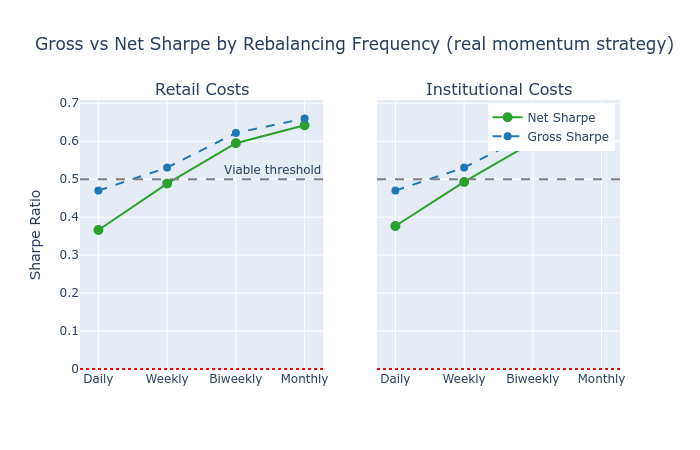

In [16]:
for col in [1, 2]:
    if col == 1:
        fig.add_hline(
            y=0.5,
            line_dash="dash",
            line_color="gray",
            annotation_text="Viable threshold",
            row=1,
            col=col,
        )
    else:
        fig.add_hline(y=0.5, line_dash="dash", line_color="gray", row=1, col=col)
    fig.add_hline(y=0, line_dash="dot", line_color="red", row=1, col=col)

fig.update_layout(
    title="Gross vs Net Sharpe by Rebalancing Frequency (real momentum strategy)",
    yaxis_title="Sharpe Ratio",
    height=450,
    showlegend=True,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99),
)

fig.show()

**Finding**: The gap between the gross (dashed) and net (solid) lines is the cost
drag, and it widens sharply toward daily cadence. Even before costs, the gross
line slopes down toward higher frequency, so the two effects reinforce rather
than offset — there is no frequency at which faster trading wins for this signal.

## 6. Cost Erosion Analysis

How much of the gross alpha is consumed by costs at each frequency?

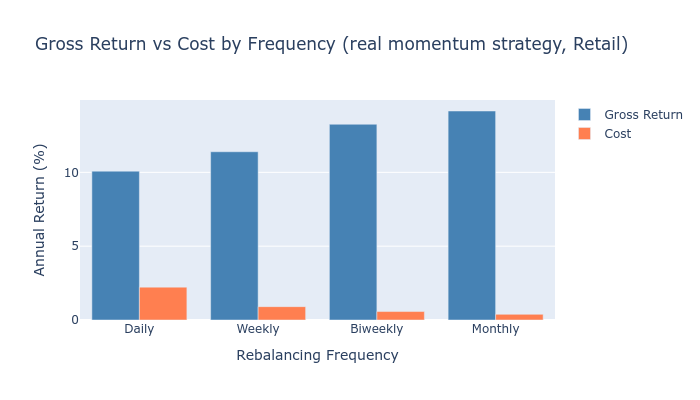

In [17]:
erosion = results_df.filter(pl.col("cost_type").str.contains("Retail")).sort(
    pl.col("frequency").map_elements(lambda x: freq_order.index(x), return_dtype=pl.Int64)
)

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=erosion["frequency"].to_list(),
        y=[r * 100 for r in erosion["gross_return"].to_list()],
        name="Gross Return",
        marker_color="steelblue",
    )
)
fig.add_trace(
    go.Bar(
        x=erosion["frequency"].to_list(),
        y=[r * 100 for r in erosion["annual_cost"].to_list()],
        name="Cost",
        marker_color="coral",
    )
)
fig.update_layout(
    title="Gross Return vs Cost by Frequency (real momentum strategy, Retail)",
    yaxis_title="Annual Return (%)",
    xaxis_title="Rebalancing Frequency",
    barmode="group",
    height=400,
)
fig.show()

## 7. Frequency Choice Under Signal Decay

The real ETF momentum signal above has no fast decay, so slower cadence wins on
both gross and cost. To show when faster trading *can* pay, this section switches
to a **hypothetical fast-decaying signal**: a fixed gross Sharpe whose captured
alpha decays exponentially with the delay between rebalances. This is a parametric
study layered on the measured per-cadence turnover, not the real momentum signal.

In [18]:
def find_optimal_frequency(
    gross_sharpe: float,
    annual_vol: float,
    cost_assumptions: CostAssumptions,
    signal_decay_rate: float = 0.1,
) -> dict:
    """Find the best net-Sharpe cadence after applying signal decay."""
    results = []

    for freq, params in FREQUENCIES.items():
        days_delay = params["trading_days_per_rebalance"]
        decay_factor = np.exp(-signal_decay_rate * days_delay)
        effective_gross_sharpe = gross_sharpe * decay_factor

        sim = simulate_frequency_comparison(effective_gross_sharpe, annual_vol, cost_assumptions)
        freq_result = sim.filter(pl.col("frequency") == freq).to_dicts()[0]
        freq_result["effective_gross_sharpe"] = effective_gross_sharpe
        freq_result["decay_factor"] = decay_factor
        results.append(freq_result)

    results_df = pl.DataFrame(results)
    optimal = results_df.filter(pl.col("net_sharpe") == pl.col("net_sharpe").max()).to_dicts()[0]

    return {
        "all_results": results_df,
        "optimal_frequency": optimal["frequency"],
        "optimal_net_sharpe": optimal["net_sharpe"],
    }

In [19]:
# Example: Fast-decaying signal (momentum)
result = find_optimal_frequency(
    gross_sharpe=2.0,
    annual_vol=0.15,
    cost_assumptions=RETAIL_COSTS,
    signal_decay_rate=0.05,  # 5% decay per day
)

print(f"\nOptimal Frequency (decay=5%/day): {result['optimal_frequency']}")
print(f"Optimal Net Sharpe: {result['optimal_net_sharpe']:.2f}")
print("\nAll frequencies:")
result["all_results"].select(
    "frequency",
    pl.col("effective_gross_sharpe").round(2).alias("eff_gross_sr"),
    pl.col("decay_factor").round(3),
    pl.col("annual_cost").round(4),
    pl.col("net_sharpe").round(2),
)


Optimal Frequency (decay=5%/day): Daily
Optimal Net Sharpe: 1.75

All frequencies:


frequency,eff_gross_sr,decay_factor,annual_cost,net_sharpe
str,f64,f64,f64,f64
"""Daily""",1.9,0.951,0.0223,1.75
"""Weekly""",1.56,0.779,0.009,1.5
"""Biweekly""",1.21,0.607,0.0057,1.17
"""Monthly""",0.7,0.35,0.0038,0.67


**Finding**: The optimal cadence only shifts upward when signal decay is fast
enough to justify the extra turnover. This is the chapter’s practical rule:
raise frequency only when the alpha half-life clearly pays for the cost drag.

## 8. Sensitivity Analysis: Cost vs Signal Decay

The optimal frequency depends on:
1. Cost structure (higher costs favor lower frequency)
2. Signal decay rate (faster decay favors higher frequency)

In [20]:
# Grid search over decay rates
decay_rates = [0.01, 0.03, 0.05, 0.10, 0.20]
sensitivity_results = []

for decay in decay_rates:
    for costs in [RETAIL_COSTS, INSTITUTIONAL_COSTS]:
        result = find_optimal_frequency(
            gross_sharpe=2.0,
            annual_vol=0.15,
            cost_assumptions=costs,
            signal_decay_rate=decay,
        )
        sensitivity_results.append(
            {
                "decay_rate": decay,
                "cost_type": costs.name,
                "optimal_freq": result["optimal_frequency"],
                "optimal_net_sharpe": result["optimal_net_sharpe"],
            }
        )

sensitivity_df = pl.DataFrame(sensitivity_results)
print("\nSensitivity: Optimal Frequency by Signal Decay and Cost Type")
sensitivity_df


Sensitivity: Optimal Frequency by Signal Decay and Cost Type


decay_rate,cost_type,optimal_freq,optimal_net_sharpe
f64,str,str,f64
0.01,"""Retail (discount broker)""","""Weekly""",1.842191
0.01,"""Institutional (algo execution)""","""Weekly""",1.848218
0.03,"""Retail (discount broker)""","""Daily""",1.792449
0.03,"""Institutional (algo execution)""","""Daily""",1.807293
0.05,"""Retail (discount broker)""","""Daily""",1.754017
0.05,"""Institutional (algo execution)""","""Daily""",1.768861
0.1,"""Retail (discount broker)""","""Daily""",1.661233
0.1,"""Institutional (algo execution)""","""Daily""",1.676077
0.2,"""Retail (discount broker)""","""Daily""",1.489019


## 9. Alpha-to-Go: Cost-Adjusted Signal Strength

When a signal has finite persistence (autocorrelation $\varphi < 1$), the
**alpha-to-go** at time $t$ is the discounted expected future return net of
execution costs. For an AR(1) signal with persistence $\varphi$ and cost
parameter $\Gamma$ (bps per unit of trading):

$$\alpha_t^{\text{go}} = \alpha_t \cdot \frac{\varphi}{1 - \varphi + \Gamma}$$

The multiplier rises with persistence $\varphi$ (more of the signal survives
to be traded on) and falls with cost $\Gamma$. Slow signals therefore retain
more alpha-to-go per unit of cost than fast ones, which can reorder which
signals are worth trading once costs are imposed.

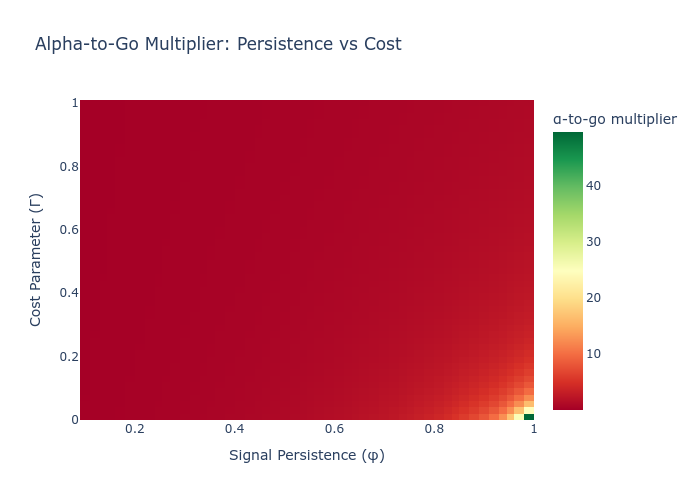

In [21]:
# Alpha-to-go heatmap
phi_values = np.linspace(0.1, 0.99, 50)  # persistence
gamma_values = np.linspace(0.01, 1.0, 50)  # cost parameter
PHI, GAMMA = np.meshgrid(phi_values, gamma_values)

alpha_to_go_ratio = PHI / (1 - PHI + GAMMA)

fig = go.Figure(
    data=go.Heatmap(
        z=alpha_to_go_ratio,
        x=np.round(phi_values, 2),
        y=np.round(gamma_values, 2),
        colorscale="RdYlGn",
        colorbar=dict(title="α-to-go multiplier"),
    )
)
fig.update_layout(
    title="Alpha-to-Go Multiplier: Persistence vs Cost",
    xaxis_title="Signal Persistence (φ)",
    yaxis_title="Cost Parameter (Γ)",
    height=500,
)
fig.show()

**Interpretation**: The multiplier rises sharply along the high-persistence
edge — slow signals (top-right) keep most of their alpha even after costs,
while fast signals (left) lose most of theirs. The ridge along the upper-right
corner shows the unbounded gain from persistence at low cost; the dark band
at low $\varphi$ shows why short-horizon signals rerank poorly after costs.

In [22]:
# Cost-adjusted IC reranking demo
signals = pl.DataFrame(
    {
        "signal": ["Momentum 1m", "Momentum 6m", "Value", "Quality"],
        "raw_ic": [0.04, 0.03, 0.025, 0.02],
        "persistence": [0.3, 0.85, 0.95, 0.92],
        "turnover_cost_bps": [0.8, 0.3, 0.1, 0.05],
    }
)
signals = signals.with_columns(
    (
        pl.col("raw_ic")
        * pl.col("persistence")
        / (1 - pl.col("persistence") + pl.col("turnover_cost_bps"))
    ).alias("cost_adj_ic")
)
signals = signals.with_columns(
    pl.col("raw_ic").rank(descending=True).alias("raw_rank"),
    pl.col("cost_adj_ic").rank(descending=True).alias("adj_rank"),
)
print("Signal Reranking After Cost Adjustment:")
signals.sort("adj_rank")

Signal Reranking After Cost Adjustment:


signal,raw_ic,persistence,turnover_cost_bps,cost_adj_ic,raw_rank,adj_rank
str,f64,f64,f64,f64,f64,f64
"""Value""",0.025,0.95,0.1,0.158333,3.0,1.0
"""Quality""",0.02,0.92,0.05,0.141538,4.0,2.0
"""Momentum 6m""",0.03,0.85,0.3,0.056667,2.0,3.0
"""Momentum 1m""",0.04,0.3,0.8,0.008,1.0,4.0


**Interpretation**: Short-horizon momentum has the highest raw IC but ranks
*last* after cost adjustment because its low persistence ($\varphi=0.3$) and
high turnover cost erode most of the edge. Slow value and quality signals
move up in the ranking — they retain more alpha-to-go per unit of cost.

## 10. Summary Statistics

In [23]:
# Final summary table — uses each cadence's measured gross and turnover.
summary_data = []
for costs in [RETAIL_COSTS, INSTITUTIONAL_COSTS]:
    for freq, params in FREQUENCIES.items():
        be_alpha = calculate_break_even_alpha(params["annual_turnover"], costs.round_trip)
        annual_cost = params["annual_turnover"] * costs.round_trip / 10000
        net_return = params["gross_return"] - annual_cost
        net_sharpe = net_return / params["annual_vol"] if params["annual_vol"] > 0 else 0.0

        summary_data.append(
            {
                "Cost Type": "Retail" if "Retail" in costs.name else "Institutional",
                "Frequency": freq,
                "Annual TO (x)": round(params["annual_turnover"], 1),
                "Gross SR": round(params["gross_sharpe"], 2),
                "Break-even Alpha (bps)": round(be_alpha),
                "Net Sharpe": round(net_sharpe, 2),
            }
        )

summary_df = pl.DataFrame(summary_data)
print("\nSummary: Frequency Analysis (real momentum strategy)")
summary_df


Summary: Frequency Analysis (real momentum strategy)


Cost Type,Frequency,Annual TO (x),Gross SR,Break-even Alpha (bps),Net Sharpe
str,str,f64,f64,i64,f64
"""Retail""","""Daily""",22.3,0.47,223,0.37
"""Retail""","""Weekly""",9.0,0.53,90,0.49
"""Retail""","""Biweekly""",5.7,0.62,57,0.59
"""Retail""","""Monthly""",3.8,0.66,38,0.64
"""Institutional""","""Daily""",22.3,0.47,200,0.38
"""Institutional""","""Weekly""",9.0,0.53,81,0.49
"""Institutional""","""Biweekly""",5.7,0.62,52,0.6
"""Institutional""","""Monthly""",3.8,0.66,35,0.64


**Finding**: The summary table compresses the notebook into a usable trading
rule. Frequency choice should be driven by net Sharpe and break-even alpha
jointly, not by gross performance or turnover in isolation.

## 11. Key Takeaways

1. **Break-even alpha scales with measured turnover**: the real momentum signal
   turns over 22.3x annually at daily cadence — needing ~223 bps gross alpha just
   to break even at retail costs — versus 3.8x and ~38 bps at monthly cadence.

2. **Retail: favor lower frequency for this signal**: retail costs (10 bps
   round-trip) compound heavily at daily cadence. With no signal decay, monthly
   maximizes net Sharpe (0.64 vs 0.37 daily), and the gross Sharpe also favors
   monthly, so frequency erosion is unambiguous here.

3. **Institutional: more flexibility but still constrained**: institutional
   costs (9 bps round-trip) are nearly as high; smaller spreads are offset by
   larger impact. Daily becomes optimal only when signal decay is fast enough.

4. **Signal decay changes the ranking**: applying an exponential decay to the
   gross signal shifts the optimal cadence upward once the alpha lost by waiting
   outweighs the cost savings; the §7-§8 grids show this crossover explicitly.

5. **Cost-adjusted IC reranks signals**: Short-horizon momentum (highest raw
   IC) drops to last place after cost adjustment; slow value and quality
   signals rise because their persistence preserves more alpha-to-go.

6. **Practical rule**: Start with monthly, only increase frequency when the
   signal's half-life demonstrably justifies the extra turnover.

**Next**: See [`10_gross_vs_net_performance`](10_gross_vs_net_performance.ipynb) for full gross-to-net waterfall analysis.
**Book**: Chapter 18, Section 18.8 discusses practical guardrails for execution costs.